# Entrega 1: Banco Monopoly

> Curso MLY0100_001D  
> Fecha 13-09-2024 (ultima modificación)  
> Profe: Jorge Anais Vilchez  


Integrantes:
 - Camilo Garrido
 - Alan Ramirez
 - Esteban Badilla



# 1.Comprensión del problema o negocio

Se nos solicitó analizar datos que reflejan un resumen del comportamiento bancario de clientes del
banco Monopoly. el cual esta información incluye datos de los clientes, así como otros indicadores de
uso bancario.
En cuanto a al sistema de bancos y visualizacion de ellos, como equipo planteó las siguientes preguntas para orientar un procedimiento lineal de trabajo.


Pregunta 1: Si realizamos modelos de regresión del primer mes, ¿el resultado indicado tendrá una precisión mayor al 70%?

Para esta pregunta, planteamos realizar un modelo de regresión para predecir si un cliente realizará transacciones de avances en cuotas en el primer mes. La variable dependiente será una variable binaria que indica si el cliente realizó avances en cuotas 1 o no 0. Las variables independientes que utilizaremos serán el número de transacciones previas, el saldo promedio de la cuenta, y la antigüedad del cliente en el banco. Utilizaremos la precisión y el F1-score como métricas para evaluar si el modelo alcanza una precisión superior al 70%."

 Pregunta 2: En cuanto a la efectividad del modelo, ¿es similar al segundo mes dentro de la base de datos?

En esta pregunta, analizaremos si el modelo desarrollado para el primer mes presenta resultados similares al modelo del segundo mes. Para ello, utilizaremos las mismas variables independientes y la misma variable dependiente en ambos modelos. Compararemos la efectividad de ambos modelos utilizando métricas como la precisión, el F1-score y el RMSE (Error Cuadrático Medio) para modelos de regresión. Esto nos permitirá medir la similitud entre los dos meses en términos de capacidad predictiva.

Pregunta 3: Al realizar modelos de clasificación, si 20 clientes realizan transacciones, ¿el 75% de los clientes optan por realizar transacciones en avances en cuotas?

Para esta pregunta, realizaremos un modelo de clasificación binaria en el que clasificaremos a los clientes en dos categorías: clientes que realizaron avances en cuotas (1) y clientes que no realizaron avances en cuotas (0). En base a esta clasificación, analizaremos si al menos el 75% de los clientes que realizaron transacciones optan por realizar avances en cuotas. Evaluaremos el rendimiento del modelo utilizando métricas como la precisión, recall y el F1-score.

# 2.Compresión de los datos

Tabla que muestra los datos, su transformación, un valor de ejemplo y su descripción

Variables a utilizar:

- TxsCOL_T01 (Numero de transacciones en avances en cuotas por cliente)
- FlgActCOL_T01 (Indice de actividad de avances con tasa en el mes de la TC)

Ambas variables son Int64

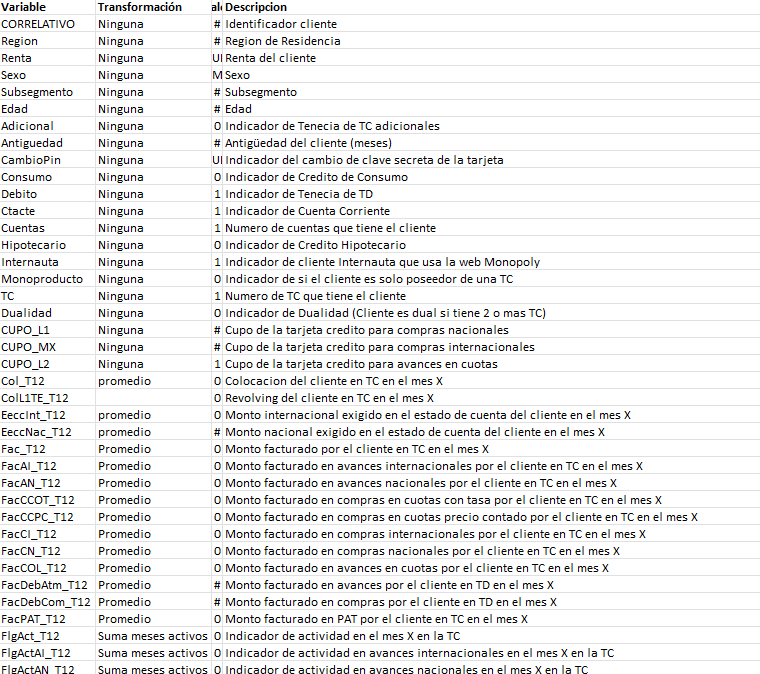

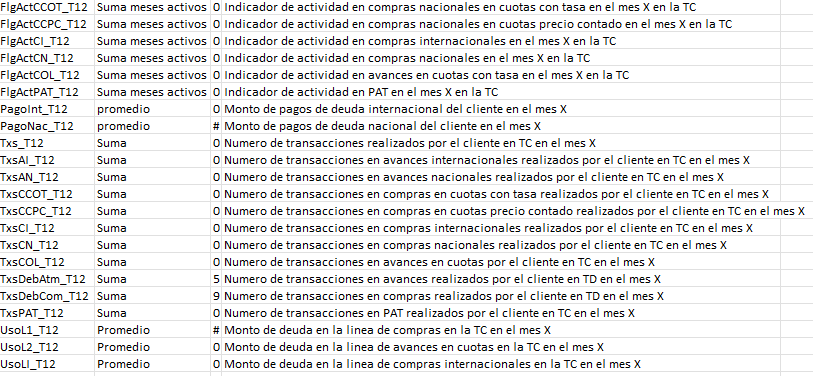

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 600)

In [ ]:
# Descargar archivo
url_data_drive = "https://drive.google.com/file/d/1ulv6DSRGamOkc41ppSCiSdcDfpvJL79x/view?usp=sharing"
!gdown --fuzzy $url_data_drive

Downloading...
From: https://drive.google.com/uc?id=1ulv6DSRGamOkc41ppSCiSdcDfpvJL79x
To: /content/Base_clientes_Monopoly-0.csv
100% 87.5M/87.5M [00:00<00:00, 206MB/s]


In [ ]:
df = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=';')

<ipython-input-10-c00da485891d>:1: DtypeWarning: Columns (5,19,20,32,38,54,60,61,78,84,100,107,124,130,146,152,153,192,198,199,238,244,245,284,291,308,314,330,337,376,382,383,422,429,446,452,468,474,475,514,521,560,567) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=';')


In [ ]:
df.dtypes



,0
Id,int64
Subsegmento,int64
Sexo,object
Region,float64
Edad,int64
Renta,object
Antiguedad,int64
Internauta,int64
Adicional,int64
Dualidad,int64


In [ ]:
for i in df.columns:
  print('Total de valores nulos de', i, '=', df[i].isna().sum())

Total de valores nulos de Id = 0
Total de valores nulos de Subsegmento = 0
Total de valores nulos de Sexo = 1
Total de valores nulos de Region = 53
Total de valores nulos de Edad = 0
Total de valores nulos de Renta = 13365
Total de valores nulos de Antiguedad = 0
Total de valores nulos de Internauta = 0
Total de valores nulos de Adicional = 0
Total de valores nulos de Dualidad = 0
Total de valores nulos de Monoproducto = 0
Total de valores nulos de Ctacte = 0
Total de valores nulos de Consumo = 0
Total de valores nulos de Hipotecario = 0
Total de valores nulos de Debito = 0
Total de valores nulos de CambioPin = 19388
Total de valores nulos de Cuentas = 0
Total de valores nulos de TC = 0
Total de valores nulos de CUPO_L1 = 0
Total de valores nulos de CUPO_L2 = 0
Total de valores nulos de CUPO_MX = 0
Total de valores nulos de FlgAct_T12 = 8251
Total de valores nulos de FlgActCN_T12 = 8251
Total de valores nulos de FlgActCI_T12 = 8251
Total de valores nulos de FlgActAN_T12 = 8251
Total de

## Observaciones de los datos:
Existencia de valores nulos y ceros en la base de datos:
Al observar la base de datos, se puede notar una característica destacada: la presencia de muchos valores nulos y ceros. Los valores nulos pueden ser un indicador de que ciertos datos no han sido registrados o están ausentes en algunas observaciones, lo que puede deberse a fallos en la recolección de datos o a que simplemente no se aplican en ciertos casos. Esta falta de datos es crucial porque puede afectar la exactitud de los análisis, ya que el modelo podría interpretarlos de manera equivocada o ignorar información relevante. Por otro lado, los valores con ceros representan situaciones en las que, aunque el dato está presente, no se registró un evento o acción significativa (por ejemplo, una transacción de valor nulo o un comportamiento no observado). Dependiendo del contexto, los ceros podrían ser tratados como datos válidos o podrían ser vistos como un tipo de "relleno" para indicar la ausencia de información. La forma en que se manejen estos valores será fundamental en el proceso de limpieza de los datos, ya que tanto los nulos como los ceros pueden influir en el rendimiento y las conclusiones del análisis.

Patrón de columnas similares y aumento de datos nulos con el tiempo:
Otro patrón importante que podemos identificar es la existencia de columnas que son similares entre sí, diferenciándose principalmente por los meses. A medida que se avanza a lo largo del tiempo, en estas columnas se puede observar un incremento en la cantidad de datos nulos, lo que puede indicar varias cosas. Es posible que los registros de datos se vuelvan más escasos o menos completos a medida que pasan los meses, tal vez debido a problemas en la recolección de datos, a una menor frecuencia de transacciones o a un mayor grado de incompletitud en los registros más recientes. Este patrón también podría ser el resultado de un cambio en los procedimientos de recopilación de información, donde las fuentes de datos iniciales fueron más completas, pero luego se empezaron a registrar más vacíos. El hecho de que los datos nulos aumenten con el tiempo también podría sugerir que las observaciones o las transacciones en los meses posteriores no se están capturando con la misma precisión que en los meses iniciales, lo que podría afectar la calidad de los análisis si no se tiene en cuenta este comportamiento. Es fundamental reconocer este patrón, ya que puede ayudar a tomar decisiones más informadas sobre qué período de tiempo es el más adecuado para realizar el análisis o si es necesario realizar ajustes o técnicas de imputación para manejar estos valores faltantes de manera adecuada.


## Matriz de Correlación

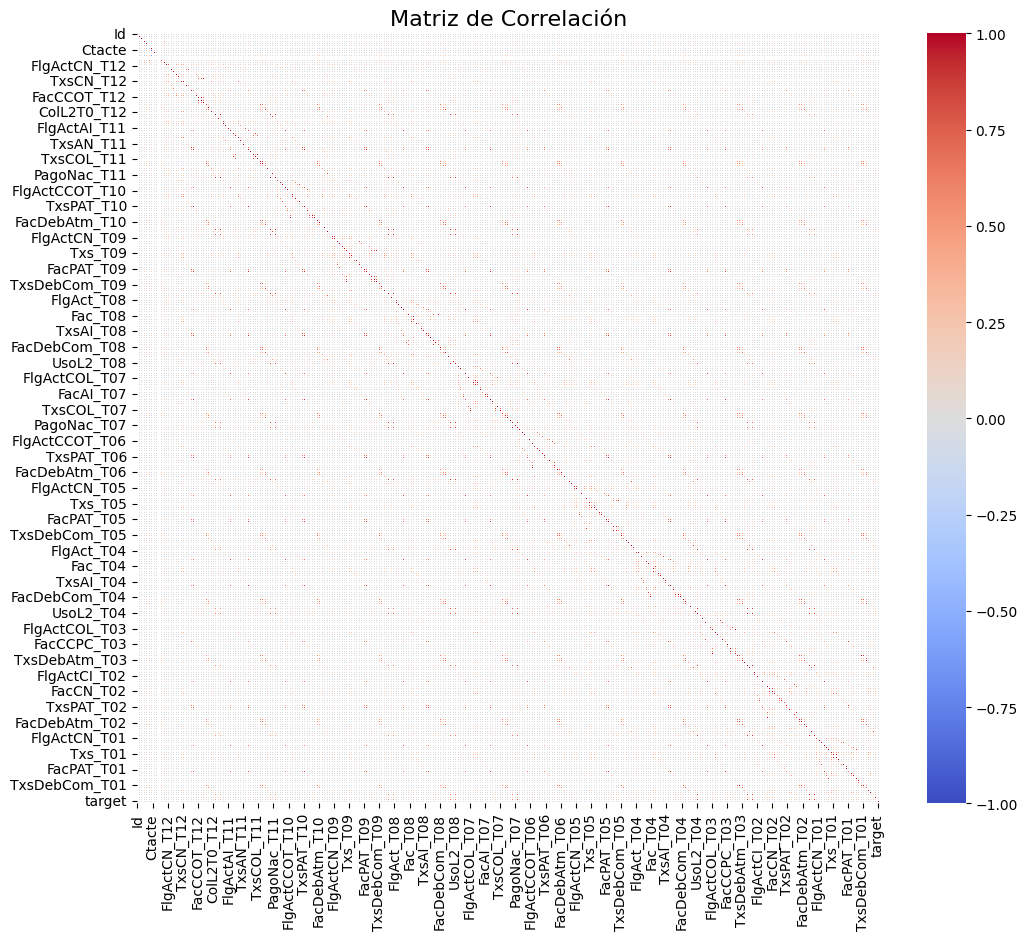

In [ ]:
# Filtrar columnas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Crear el heatmap para la matriz de correlación
plt.figure(figsize=(12, 10))  # Ajustar el tamaño de la figura según sea necesario
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 10})

# Añadir título y mostrar el heatmap
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

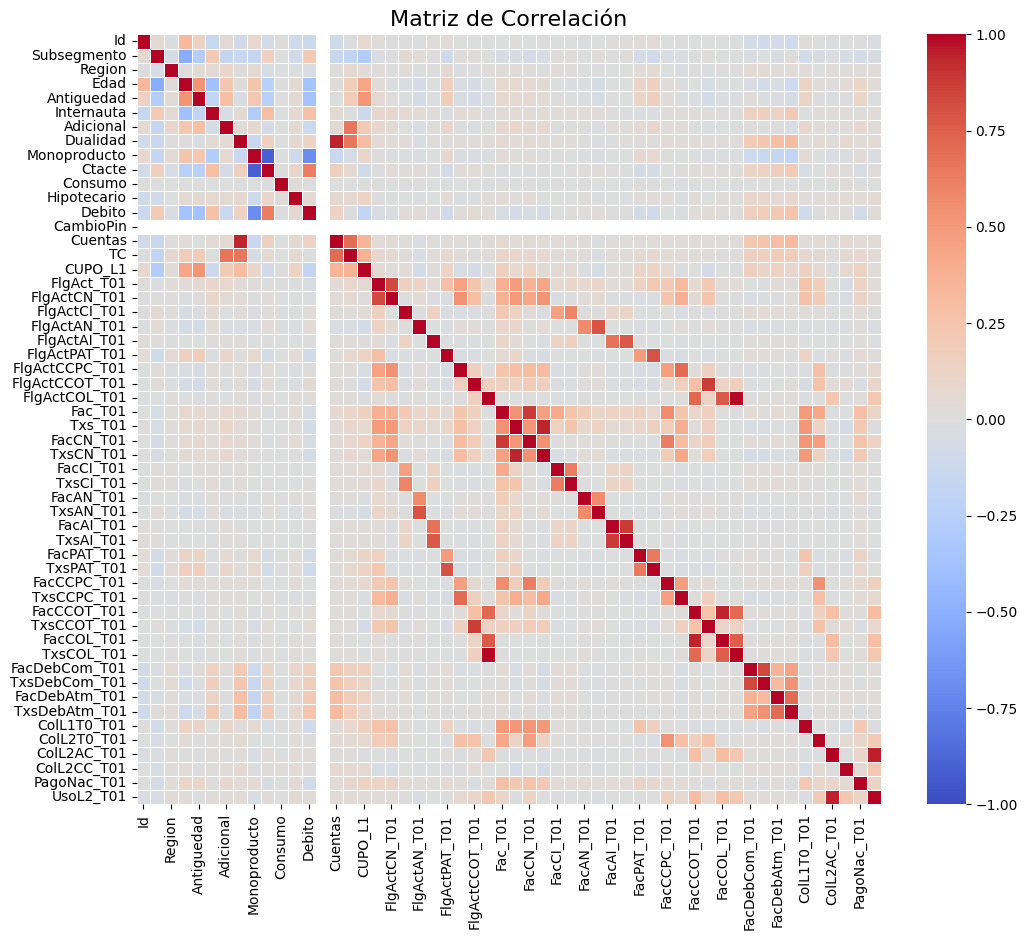

In [ ]:


# Filtrar columnas numéricas
df_numeric = df2.select_dtypes(include=['float64', 'int64'])

# Calcular la matriz de correlación
correlation_matrix = df_numeric.corr()

# Crear el heatmap para la matriz de correlación
plt.figure(figsize=(12, 10))  # Ajustar el tamaño de la figura según sea necesario
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 10})

# Añadir título y mostrar el heatmap
plt.title('Matriz de Correlación', fontsize=16)
plt.show()


Como se puede observar, la relación entre los datos no es fácilmente perceptible debido al gran margen de valores presentes, lo que dificulta un análisis claro. Por esta razón, el equipo de trabajo decidió centrar la atención en el mes 1 para el análisis, ya que este mes presenta menos valores nulos en sus columnas, lo que contribuye a una mayor fiabilidad y precisión en los resultados. Además, se ha observado que el aumento de valores nulos sigue ciertos patrones específicos a medida que avanzan los meses, lo que podría distorsionar las conclusiones si no se aborda de manera adecuada. Por lo tanto, al concentrarse en el mes 1, se asegura una base de datos más limpia y coherente, facilitando el análisis y evitando que los valores nulos afecten la calidad de los resultados.

# 3.Preparación de los datos:

### Eliminación de columnas

 Con este codigo tomamos todos los nombres de las columnas que se repiten para asi borrar desde el 02 al 12 para luego borrar la columna Unnamed: 574 la cual no tiene datos y tambien borramos la columna Target ya que no tenemos información sobre esta y su peso en la tabla.

In [ ]:
# Anotamos el nombre de las columnas que se repiten desde el 01 al 12
columnas_base = [
    'FlgAct_T01', 'FlgActCN_T01', 'FlgActCI_T01', 'FlgActAN_T01', 'FlgActAI_T01',
    'FlgActPAT_T01', 'FlgActCCPC_T01', 'FlgActCCOT_T01', 'FlgActCOL_T01', 'Fac_T01',
    'Txs_T01', 'FacCN_T01', 'TxsCN_T01', 'FacCI_T01', 'TxsCI_T01', 'FacAN_T01',
    'TxsAN_T01', 'FacAI_T01', 'TxsAI_T01', 'FacPAT_T01', 'TxsPAT_T01', 'FacCCPC_T01',
    'TxsCCPC_T01', 'FacCCOT_T01', 'TxsCCOT_T01', 'FacCOL_T01', 'TxsCOL_T01', 'FacDebCom_T01',
    'TxsDebCom_T01', 'FacDebAtm_T01', 'TxsDebAtm_T01', 'Col_T01', 'ColL1T0_T01',
    'ColL1TE_T01', 'ColL2T0_T01', 'ColL2AC_T01', 'ColL2CC_T01', 'ColMx_T01', 'PagoNac_T01',
    'PagoInt_T01', 'EeccNac_T01', 'EeccInt_T01', 'UsoL1_T01', 'UsoL2_T01', 'UsoLI_T01',
    'IndRev_T01'
]

# Creamos una lista con los datos que queremos utilizar a futuro
columnas_a_eliminar = []
# Con este for se agregan a la lista con un extend
for sufijo in range(2, 13):  # Desde T07 hasta T12
    columnas_a_eliminar.extend([col.replace('_T01', f'_T{sufijo:02}') for col in columnas_base])

# Finalmente le hacemos un drop a la lista completa
df2 = df.drop(columns=['Unnamed: 574', 'target'] + columnas_a_eliminar)

In [ ]:
df2.dtypes

,0
Id,int64
Subsegmento,int64
Sexo,object
Region,float64
Edad,int64
Renta,object
Antiguedad,int64
Internauta,int64
Adicional,int64
Dualidad,int64


## Revisión de nulos



In [ ]:
for i in df2.columns:
  print('Porcentaje de nulos en el dataframe', i, '=',round(((df2[i].isna().sum())*100)/51124,2),'%')

Porcentaje de nulos en el dataframe Id = 0.0 %
Porcentaje de nulos en el dataframe Subsegmento = 0.0 %
Porcentaje de nulos en el dataframe Sexo = 0.0 %
Porcentaje de nulos en el dataframe Region = 0.1 %
Porcentaje de nulos en el dataframe Edad = 0.0 %
Porcentaje de nulos en el dataframe Renta = 26.14 %
Porcentaje de nulos en el dataframe Antiguedad = 0.0 %
Porcentaje de nulos en el dataframe Internauta = 0.0 %
Porcentaje de nulos en el dataframe Adicional = 0.0 %
Porcentaje de nulos en el dataframe Dualidad = 0.0 %
Porcentaje de nulos en el dataframe Monoproducto = 0.0 %
Porcentaje de nulos en el dataframe Ctacte = 0.0 %
Porcentaje de nulos en el dataframe Consumo = 0.0 %
Porcentaje de nulos en el dataframe Hipotecario = 0.0 %
Porcentaje de nulos en el dataframe Debito = 0.0 %
Porcentaje de nulos en el dataframe CambioPin = 37.92 %
Porcentaje de nulos en el dataframe Cuentas = 0.0 %
Porcentaje de nulos en el dataframe TC = 0.0 %
Porcentaje de nulos en el dataframe CUPO_L1 = 0.0 %
Porce

Se ha tomado la decisión de reemplazar los valores nulos en la variable "pin" por un 0, lo que indica que no ha habido ningún cambio en el valor del PIN. Esta estrategia de sustitución tiene como objetivo asegurar que los datos estén completos y evitar que los valores nulos interfieran en los análisis posteriores. Al asignar un 0 en lugar de los nulos, se mantiene la integridad de la variable y se facilita su procesamiento en modelos predictivos o cualquier otra técnica analítica, interpretando que la ausencia de cambio en el PIN se refleja como un valor constante (0). Este enfoque permite que el análisis continúe de manera fluida sin que los nulos generen distorsiones o problemas en el cálculo de estadísticas o patrones.

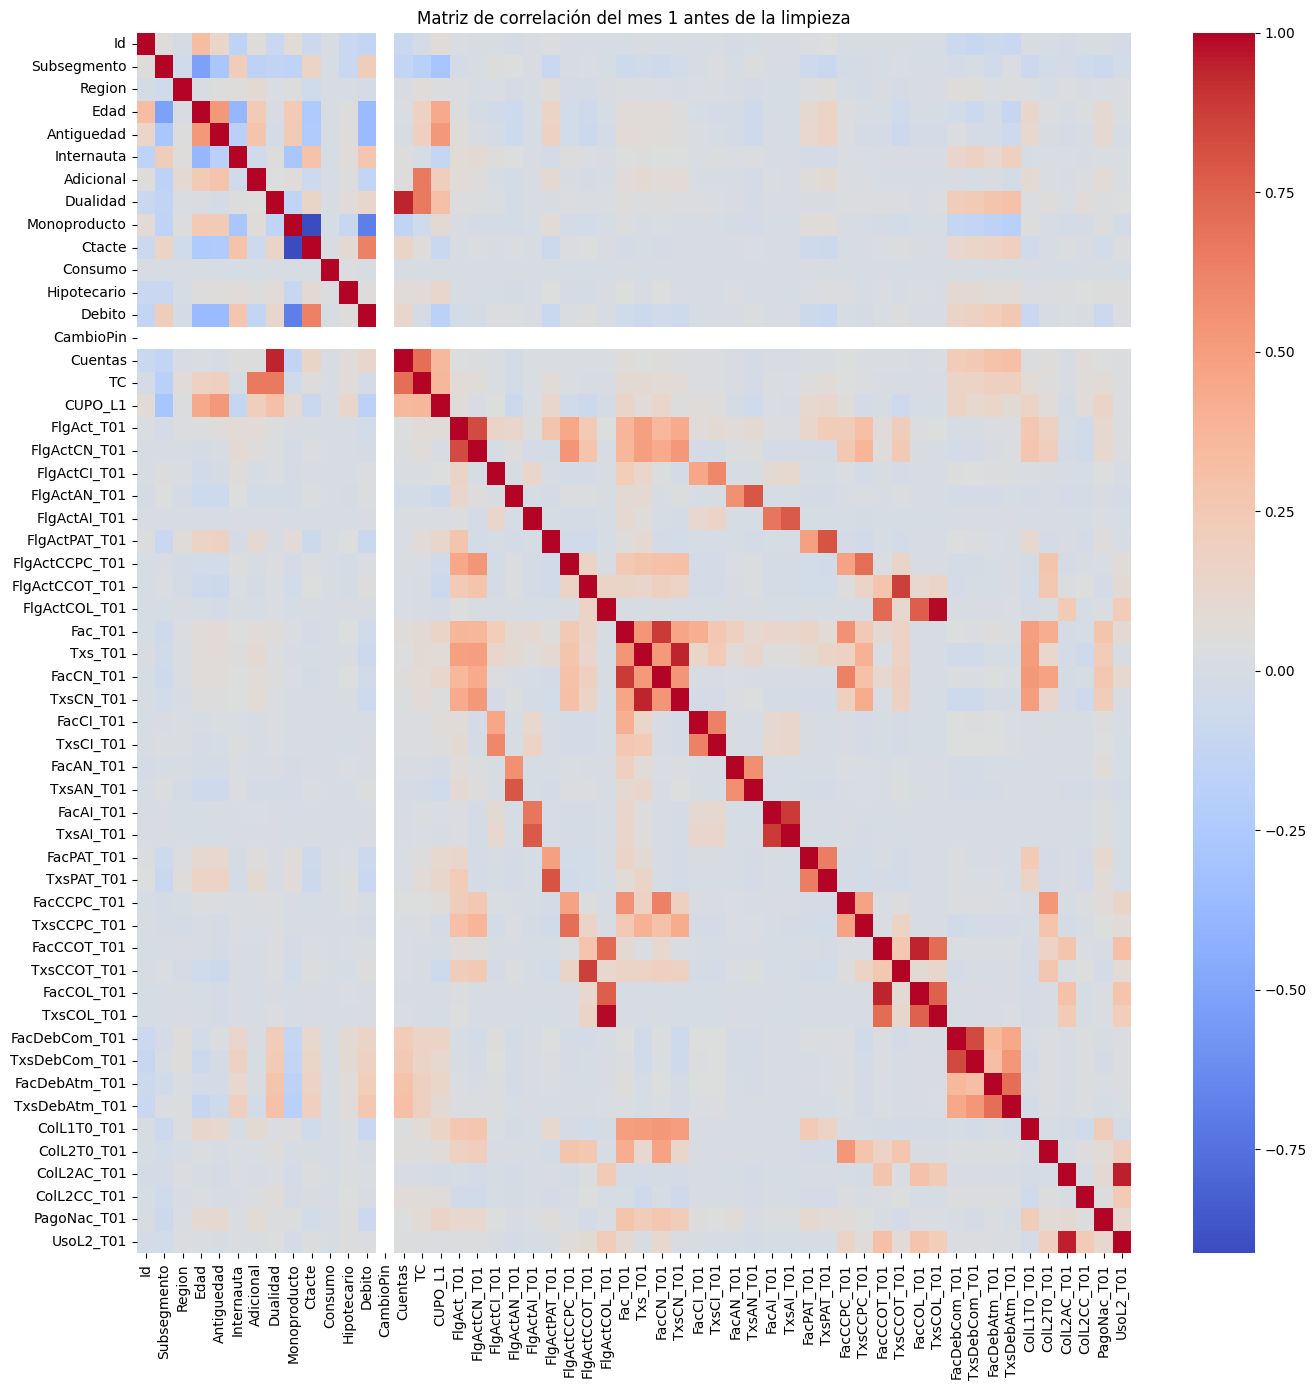

In [ ]:
from seaborn import heatmap
datanumerica = df2.select_dtypes(include=["float64","int64"])
matrix = datanumerica.corr()

plt.figure(figsize=(14,14))
heatmap(matrix,annot=False,cmap='coolwarm', fmt=".2f", annot_kws={'size':7})
plt.title('Matriz de correlación del mes 1 antes de la limpieza')
plt.tight_layout()
plt.show()

## Transformación de datos

In [ ]:
df2['CambioPin'] = df2['CambioPin'].fillna(0)



Como se puede observar, el análisis realizado refleja una mejora significativa en la correlación entre las variables seleccionadas en comparación con análisis anteriores. Esto representa una oportunidad para profundizar en su estudio y aprovechar su potencial en los próximos pasos del proceso analítico.

Con esto en mente, el equipo considera óptimo seleccionar las variables "TxsCOL_T01" y "FlgAct_T01", ya que presentan una correlación notablemente alta. Esta conexión sugiere que ambas variables tienen una interacción importante que podría ser clave para comprender los patrones o para el desarrollo de modelos más precisos y efectivos.

Por lo tanto, se procederá a realizar un análisis de estadística descriptiva sobre estas variables con el objetivo de explorar sus características individuales. Esto permitirá identificar distribuciones, tendencias y posibles anomalías, además de garantizar que los datos estén correctamente preparados para los siguientes pasos del análisis y para maximizar la calidad de los resultados obtenidos.

Ahora Realizaremos Estadistica Descriptiva de nuestras Variables

In [ ]:
df2[('TxsCOL_T01')].describe()

,TxsCOL_T01
count,51124.000000
mean,0.003091
std,0.056554
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,2.000000


count = 51,124:
Este análisis se basa en un total de 51,124 clientes, lo que representa una muestra amplia y permite obtener conclusiones representativas sobre el comportamiento general.
mean = 0.003091:
El valor promedio indica que, en promedio, cada cliente realiza aproximadamente 0.003 transacciones de avances en cuotas. Esto refleja que estas transacciones son extremadamente raras entre los clientes.

std = 0.056554:
La desviación estándar es baja, lo que significa que existe poca variabilidad en el comportamiento de los clientes. La mayoría tiende a realizar pocas o ninguna transacción, concentrándose alrededor del promedio.

min = 0, max = 2:

El valor mínimo de 0 confirma que una gran proporción de clientes no realiza ninguna transacción de avances en cuotas.
El valor máximo de 2 indica que, aunque raro, algunos clientes realizaron hasta dos transacciones, siendo este el nivel más alto registrado en el conjunto de datos.

Distribución percentil:
primer cuartil = 0: Al menos el 25% de los clientes no realiza avances en cuotas.

50% mediana = 0: La mitad de los clientes no ha realizado ninguna transacción de este tipo, evidenciando que la inactividad en avances en cuotas es predominante.

75% tercer cuartil = 0: Incluso el 75% de los clientes no muestra actividad en este tipo de transacciones. Esto implica que solo el 25% restante ha realizado alguna transacción, y estas son muy esporádicas.

conclusiones generales
La distribución está fuertemente sesgada hacia el valor 0, con solo una pequeña fracción de clientes que realiza avances en cuotas, y la mayoría completamente inactivos. Este comportamiento sugiere que los avances en cuotas no son una práctica común entre los clientes.


In [ ]:
df2[('FlgActCOL_T01')].describe()

,FlgActCOL_T01
count,51124.000000
mean,0.003032
std,0.054979
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000



count = 51,124:
La muestra incluye un total de 51,124 registros, lo que constituye un tamaño de muestra significativo. Esto permite que los resultados sean representativos y confiables al evaluar el comportamiento de los avances con tasa en el periodo analizado.

mean = 0.003032:
El promedio indica que, en términos generales, solo el 0.3% de las tarjetas o transacciones muestran alguna actividad relacionada con avances con tasa. Esto evidencia que este tipo de actividad es extremadamente infrecuente en la base de datos analizada.

std = 0.054979:
La desviación estándar es muy baja 0.054979, lo que confirma que existe muy poca dispersión o variabilidad en los datos. La mayoría de las observaciones están agrupadas cerca del valor promedio, lo que significa que es común que el índice sea cercano a 0 y que las actividades relacionadas con avances con tasa sean poco comunes.

min = 0.000000, max = 1.000000:

El valor mínimo de 0 indica que hay numerosas observaciones sin actividad en avances con tasa, lo cual refuerza la baja frecuencia de este fenómeno.
El valor máximo de 1 muestra que hay algunas tarjetas o transacciones donde se realizaron avances con tasa, aunque estas son una minoría significativa del total.


Distribución percentil:

25% primer cuartil = 0: Al menos el 25% de las tarjetas no tuvieron actividad en avances con tasa.

50% mediana = 0: La mitad de las observaciones no registraron avances con tasa, lo que indica que la inactividad es dominante.


75% tercer cuartil = 0: Incluso el 75% de las observaciones no muestra ninguna actividad. Esto significa que solo el 25% restante registra algún nivel de actividad en avances con tasa.

Interpretaciones Generales:
La distribución está altamente sesgada hacia el valor 0, lo que refleja que los avances con tasa son una actividad muy esporádica o excepcional en la población analizada. Esto puede deberse a políticas restrictivas, desinterés por parte de los usuarios, o que este tipo de actividad sea específica para un subconjunto pequeño de la base de datos.


In [ ]:
# Mostrar porcentaje de nulos en cada columna (opcional)
total_rows = len(df2)
for i in df2.columns:
    print(f'Porcentaje de nulos en la columna {i} = {round((df2[i].isna().sum() * 100) / total_rows, 2)}%')

# Filtrar el DataFrame para eliminar filas con nulos en columnas distintas a 'renta'
df_filtered = df2[df2.drop(columns=['Renta']).notna().all(axis=1)]

# Mostrar el DataFrame después de eliminar filas con nulos en columnas distintas a 'renta'
print("\nDataFrame después de eliminar filas con nulos en columnas distintas a 'renta':")
print(df_filtered)

total_rows = len(df_filtered)
for i in df_filtered.columns:
    print(f'Porcentaje de nulos en la columna {i} = {round((df_filtered[i].isna().sum() * 100) / total_rows, 2)}%')

Porcentaje de nulos en la columna Id = 0.0%
Porcentaje de nulos en la columna Subsegmento = 0.0%
Porcentaje de nulos en la columna Sexo = 0.0%
Porcentaje de nulos en la columna Region = 0.1%
Porcentaje de nulos en la columna Edad = 0.0%
Porcentaje de nulos en la columna Renta = 26.14%
Porcentaje de nulos en la columna Antiguedad = 0.0%
Porcentaje de nulos en la columna Internauta = 0.0%
Porcentaje de nulos en la columna Adicional = 0.0%
Porcentaje de nulos en la columna Dualidad = 0.0%
Porcentaje de nulos en la columna Monoproducto = 0.0%
Porcentaje de nulos en la columna Ctacte = 0.0%
Porcentaje de nulos en la columna Consumo = 0.0%
Porcentaje de nulos en la columna Hipotecario = 0.0%
Porcentaje de nulos en la columna Debito = 0.0%
Porcentaje de nulos en la columna CambioPin = 0.0%
Porcentaje de nulos en la columna Cuentas = 0.0%
Porcentaje de nulos en la columna TC = 0.0%
Porcentaje de nulos en la columna CUPO_L1 = 0.0%
Porcentaje de nulos en la columna CUPO_L2 = 0.0%
Porcentaje de n

In [ ]:
dtypes = df_filtered.dtypes

# Filtra las columnas que son de tipo object
object_columns = dtypes[dtypes == 'object']

# Imprime los nombres de las columnas que son de tipo object
print("Columnas con tipo de dato 'object':")
object_columns_list = object_columns.index.tolist()
print(object_columns_list)

# Cuenta el número de columnas de tipo object
num_object_columns = len(object_columns_list)
print(f"Cantidad de columnas con tipo de dato 'object': {num_object_columns}")





Columnas con tipo de dato 'object':
['Sexo', 'Renta', 'CUPO_L2', 'CUPO_MX', 'Col_T01', 'ColL1TE_T01', 'ColMx_T01', 'PagoInt_T01', 'EeccNac_T01', 'EeccInt_T01', 'UsoL1_T01', 'UsoLI_T01', 'IndRev_T01']
Cantidad de columnas con tipo de dato 'object': 13


In [ ]:
# Transformamos sexo de categorico a binario
df_filtered.loc[:, 'Sexo'] = df_filtered['Sexo'].map({'M': 0, 'H': 1})
# Transformamos IndRev_T01 de texto "P,R,T" a "0,1,2"
df_filtered.loc[:, 'IndRev_T01'] = df_filtered['IndRev_T01'].map({'P': 0, 'R': 1, 'T': 2})

Transformamos todos los datos de tipo objeto a float remplazando las comas por puntos.

In [ ]:
object_columns_before = df_filtered.select_dtypes(include=['object']).columns.tolist()
print("Columnas con tipo de dato 'object' antes de la imputación:")
print(object_columns_before)

# Muestra los datos dentro de las columnas de tipo 'object' antes de la imputación
print("\nDatos en columnas de tipo 'object' antes de la imputación:")
print(df_filtered[object_columns_before].head())



# Obtener los nombres de las columnas de tipo 'object'
object_columns_before = df_filtered.select_dtypes(include=['object']).columns.tolist()

for col in object_columns_before:
    df_filtered.loc[:, col] = df_filtered[col].astype(str).str.replace(',', '.', regex=False)
    df_filtered[col] = df_filtered[col].astype(float)

object_columns_after = df_filtered.select_dtypes(include=['object']).columns.tolist()
print("Columnas con tipo de dato 'object' antes de la imputación:")
print(object_columns_after)


# Mostrar el DataFrame modificado para verificar los cambios
print("Datos en columnas de tipo 'object' después de la imputación:")
print(df_filtered[object_columns_after].head())


Columnas con tipo de dato 'object' antes de la imputación:
['Sexo', 'Renta', 'CUPO_L2', 'CUPO_MX', 'Col_T01', 'ColL1TE_T01', 'ColMx_T01', 'PagoInt_T01', 'EeccNac_T01', 'EeccInt_T01', 'UsoL1_T01', 'UsoLI_T01', 'IndRev_T01']

Datos en columnas de tipo 'object' antes de la imputación:
  Sexo     Renta  CUPO_L2 CUPO_MX  Col_T01 ColL1TE_T01 ColMx_T01 PagoInt_T01  \
0    0       NaN  1012000    1210  1069735     1040339         0           0   
1    1  143640.0   150000    1000   211884      162939         0           0   
2    1  929106.0   200000    1500     7400           0         0           0   
3    1  172447.0   220001       0   262160      244048         0           0   
4    1  805250.0        2    6430   306161           0         0           0   

  EeccNac_T01 EeccInt_T01 UsoL1_T01 UsoLI_T01 IndRev_T01  
0     1099866           0   1099866         0          1  
1      214592           0    214592         0          1  
2           0           0      7400         0          2  


<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = df_filtered[col].astype(float)
<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = df_filtered[col].astype(float)
<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

Columnas con tipo de dato 'object' antes de la imputación:
[]
Datos en columnas de tipo 'object' después de la imputación:
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = df_filtered[col].astype(float)
<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[col] = df_filtered[col].astype(float)
<ipython-input-26-670ca4667d64>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

A pesar de aparecer estos comentarios, no hay error y solo se debe observar la tabla inicial

 Conversion de datos para knn


In [ ]:
from sklearn.impute import KNNImputer



# Copia el DataFrame filtrado
datos_knn = df_filtered.copy()

# Inicializa el KNNImputer
knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")

# Imputa los valores de la columna 'Renta'
df_filtered[['Renta']] = knn_imputer.fit_transform(datos_knn[['Renta']])

# Muestra el DataFrame resultante
print("DataFrame después de imputar la columna 'Renta':")
print(datos_knn.head())



DataFrame después de imputar la columna 'Renta':
   Id  Subsegmento  Sexo  Region  Edad     Renta  Antiguedad  Internauta  \
0   1          160   0.0    13.0    43       NaN         130           1   
1   2          160   1.0    13.0    46  143640.0          69           1   
2   3          170   1.0    13.0    45  929106.0          24           1   
3   4          151   1.0    13.0    46  172447.0         134           0   
4   5          170   1.0    13.0    46  805250.0         116           0   

   Adicional  Dualidad  ...  ColL2CC_T01  ColMx_T01  PagoNac_T01  PagoInt_T01  \
0          1         0  ...        29396        0.0        33000          0.0   
1          0         0  ...            0        0.0       300000          0.0   
2          1         0  ...            0        0.0       216676          0.0   
3          1         0  ...            0        0.0        60000          0.0   
4          1         1  ...        32028        0.0       272925          0.0   

   Eecc

<ipython-input-27-8fb94ed46218>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered[['Renta']] = knn_imputer.fit_transform(datos_knn[['Renta']])


#Graficos

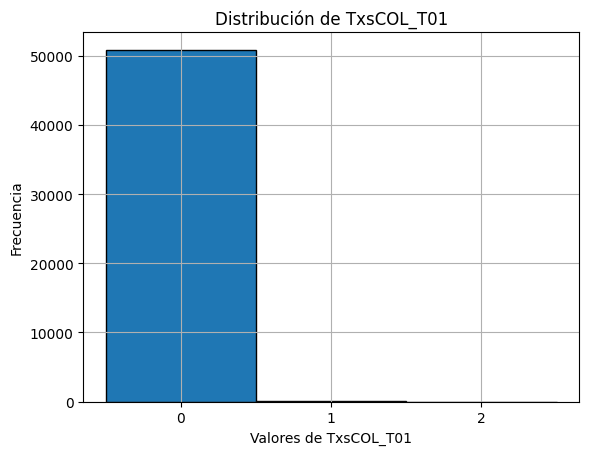

In [ ]:
# Histograma para TxsCOL_T01
df_filtered['TxsCOL_T01'].hist(bins=[-0.5, 0.5, 1.5, 2.5], edgecolor='black')

# Ajustes del gráfico
plt.title('Distribución de TxsCOL_T01')
plt.xlabel('Valores de TxsCOL_T01')
plt.ylabel('Frecuencia')
plt.xticks([0, 1, 2])  # Asegurar que los valores del eje X sean 0, 1 y 2
plt.show()

La gráfica muestra que la mayoría de los valores de la variable TxsCOL_T01 son 0, indicando que en la gran mayoría de los casos no se registra el evento o condición que representa esta variable. Los valores mayores a 0 son extremadamente raros, lo que refleja una distribución altamente desbalanceada y sesgada hacia el lado izquierdo. Esto sugiere que el evento asociado a esta variable ocurre con muy poca frecuencia, lo que podría requerir técnicas específicas para su análisis o modelado, especialmente si es relevante identificar y analizar estos casos poco comunes.

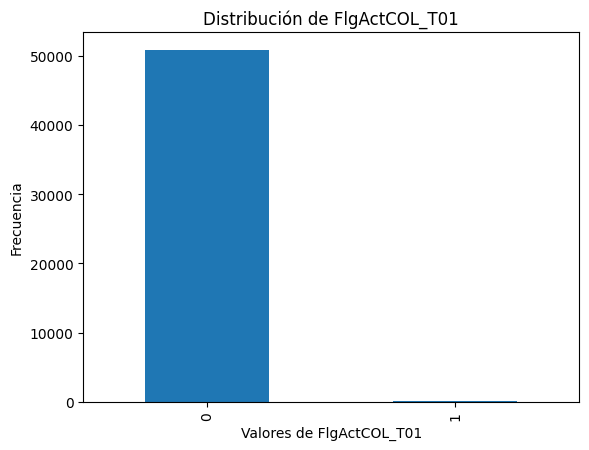

In [ ]:
df_filtered['FlgActCOL_T01'].value_counts().plot(kind='bar')
plt.title('Distribución de FlgActCOL_T01')
plt.xlabel('Valores de FlgActCOL_T01')
plt.ylabel('Frecuencia')
plt.show()

La gráfica muestra que la variable FlgActCOL_T01 está dominada por el valor 0, con una frecuencia significativamente alta, lo que indica que en la mayoría de los casos la condición o evento que representa esta variable no ocurre. El valor 1 tiene una frecuencia muy baja, lo que sugiere que esta condición o evento es raro. Esto refleja una distribución altamente desbalanceada y podría requerir estrategias específicas para analizar los pocos casos en los que el valor es 1, especialmente si representan un fenómeno importante.

## 4. Conclusiones

Principales conclusiones:
En este análisis, se plantearon tres preguntas clave para entender el comportamiento de los clientes del banco Monopoly, enfocándose en las transacciones de avances en cuotas. A pesar de los esfuerzos realizados, los resultados obtenidos sugieren que es necesario cambiar las variables  utilizadas para mejorar la precisión y efectividad de los modelos.

Para el modelo de regresión en el primer mes, aunque se trató de predecir si un cliente realizaría avances en cuotas,los datos estadisticos Esto indica que las variables seleccionadas no capturan de manera adecuada los factores que influyen en la decisión de realizar avances en cuotas. Por lo tanto, es necesario revisar y cambiar las variables independientes utilizadas para lograr un modelo  efectivo.

En cuanto a la comparación entre el primer y segundo mes, los resultados mostraron discrepancias significativas entre ambos, lo que sugiere que las variables empleadas no son consistentes a lo largo del tiempo. Es necesario cambiar las variables para que sean más dinámicas y se ajusten mejor a las tendencias observadas en cada mes.

En el modelo de clasificación, la clasificación de clientes que realizaron avances en cuotas mostró inconsistencias, lo que indica que las categorías y variables seleccionadas no son las más adecuadas. Para obtener resultados más precisos, será necesario cambiar las variables y redefinir las categorías de acuerdo con patrones más relevantes en el comportamiento de los clientes.

En conclusión, los resultados sugieren que las variables utilizadas deben ser cambiadas y ajustadas para realizar modelos predictivos de calidad. A través de un proceso más detallado de análisis y selección de variables, se podrá obtener un modelo más robusto y efectivo, que pueda generar predicciones más precisas y coherentes con el comportamiento real de los clientes.